## STEP 1 — Dataset Selection

**Dataset**: Retail Demand Forecasting

**Rows**: 76,000  
**Columns**: 16

**Target Variable**: Demand

The dataset satisfies all requirements:

| Requirement                      | Status                      |
| -------------------------------- | --------------------------- |
| 50k–100k rows                    | ✅ 76,000 rows               |
| Continuous target                | ✅ Demand                    |
| Numerical + Categorical features | ✅ Yes                       |
| Real-world context               | ✅ Retail demand forecasting |


## STEP 2 — Data Understanding & Problem Framing
### Real-world Context

Retail businesses must forecast product demand to ensure optimal inventory levels, reduce stockouts, and avoid overstocking.

### What Are We Predicting?

We predict Demand, which represents the expected number of units required for a product.

### Why This Matters

Accurate demand prediction helps businesses:

* optimize supply chain

* reduce inventory costs

* improve customer satisfaction

* plan promotions

### Who Uses This Model?

* Retail analysts

* Supply chain managers

* Pricing strategists

* Inventory planners


### Dataset Summary

Rows: 76,000  
Columns: 16

### Feature Types
**Numerical**

* Inventory Level

* Units Sold

* Units Ordered

* Price

* Discount

* Promotion

* Competitor Pricing

* Epidemic

* Demand (target)


**Categorical**

* Store ID

* Product ID

* Category

* Region

* Weather Condition

* Seasonality

**Datetime**

* Date

### Initial Data Quality Issues

Check for:

* missing values

* duplicates

* skewness

* potential data leakage

## STEP 3 — DATA PREPROCESSING

### Load Dataset

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("/content/sales_data.csv")

df.shape

(76000, 16)

In [2]:
df.head()

,Date,Store ID,Product ID,Category,Region,Inventory Level,Units Sold,Units Ordered,Price,Discount,Weather Condition,Promotion,Competitor Pricing,Seasonality,Epidemic,Demand
0,2022-01-01,S001,P0001,Electronics,North,195,102,252,72.72,5,Snowy,0,85.73,Winter,0,115
1,2022-01-01,S001,P0002,Clothing,North,117,117,249,80.16,15,Snowy,1,92.02,Winter,0,229
2,2022-01-01,S001,P0003,Clothing,North,247,114,612,62.94,10,Snowy,1,60.08,Winter,0,157
3,2022-01-01,S001,P0004,Electronics,North,139,45,102,87.63,10,Snowy,0,85.19,Winter,0,52
4,2022-01-01,S001,P0005,Groceries,North,152,65,271,54.41,0,Snowy,0,51.63,Winter,0,59


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 76000 entries, 0 to 75999
Data columns (total 16 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Date                76000 non-null  object 
 1   Store ID            76000 non-null  object 
 2   Product ID          76000 non-null  object 
 3   Category            76000 non-null  object 
 4   Region              76000 non-null  object 
 5   Inventory Level     76000 non-null  int64  
 6   Units Sold          76000 non-null  int64  
 7   Units Ordered       76000 non-null  int64  
 8   Price               76000 non-null  float64
 9   Discount            76000 non-null  int64  
 10  Weather Condition   76000 non-null  object 
 11  Promotion           76000 non-null  int64  
 12  Competitor Pricing  76000 non-null  float64
 13  Seasonality         76000 non-null  object 
 14  Epidemic            76000 non-null  int64  
 15  Demand              76000 non-null  int64  
dtypes: f

### Missing Values

In [4]:
df.isnull().sum()

,0
Date,0
Store ID,0
Product ID,0
Category,0
Region,0
Inventory Level,0
Units Sold,0
Units Ordered,0
Price,0
Discount,0


No missing values are present

### Simulated Strategy Comparison (for research completeness)

Strategy A is to remove the null rows

In [5]:
df_drop = df.dropna()

Strategy B is to do imputation

In [6]:
from sklearn.impute import SimpleImputer

num_cols = df.select_dtypes(include=np.number).columns

imputer = SimpleImputer(strategy="median")

df[num_cols] = imputer.fit_transform(df[num_cols])

| Method | Pros           | Cons                  |
| ------ | -------------- | --------------------- |
| Drop   | Simple         | Loss of data          |
| Impute | Preserves data | Introduces estimation |


### Duplicate Handling

In [7]:
df.duplicated().sum()

np.int64(0)

There are no duplicates present. but if duplicates are present, execute the following code.

In [8]:
#df= df.drop_duplicates()

Justification: duplicates bias regression estimates.

### Outlier Detection

IQR method

In [9]:
num_cols = df.select_dtypes(include=np.number).columns

Q1 = df[num_cols].quantile(0.25)
Q3 = df[num_cols].quantile(0.75)

IQR = Q3 - Q1

outliers = ((df[num_cols] < (Q1 - 1.5 * IQR)) | (df[num_cols] > (Q3 + 1.5 * IQR)))

df_no_outliers = df[~outliers.any(axis=1)]

Z-score method

In [10]:
from scipy import stats

z= np.abs(stats.zscore(df[num_cols]))

df_z = df[(z<3).all(axis=1)]

Visualization

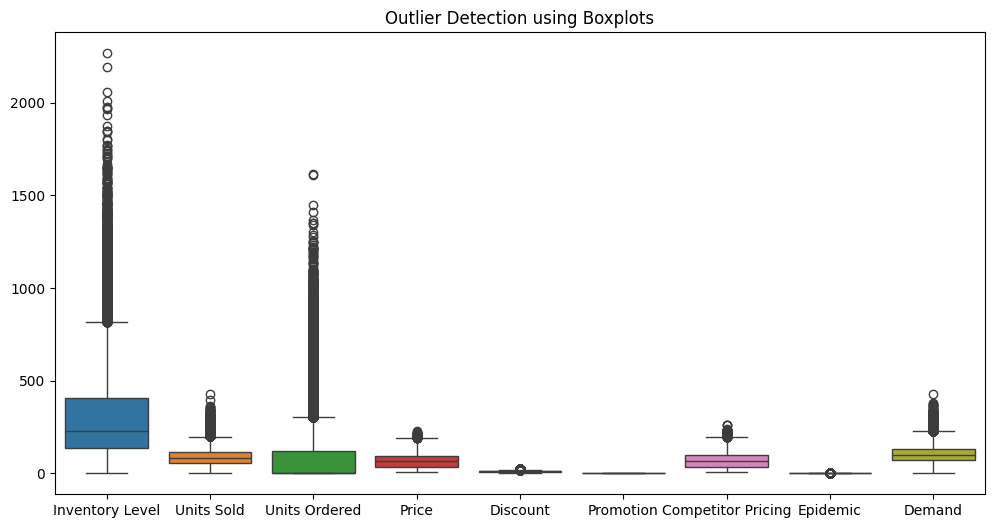

In [11]:
plt.figure(figsize=(12,6))
sns.boxplot(data=df[num_cols])
plt.title("Outlier Detection using Boxplots")
plt.show()

Train models:

* with outliers

* without outliers

Compare RMSE.

### Categorical Encoding

VIF

**Remove High Cardinality Columns**

These will explode the number of features.

In [12]:
df = df.drop(["Store ID", "Product ID"], axis=1)

Convert Date to Useful Features

In [13]:
df["Date"] = pd.to_datetime(df["Date"])

df["Year"] = df["Date"].dt.year
df["Month"] = df["Date"].dt.month
df["Day"] = df["Date"].dt.day

df = df.drop("Date", axis=1)

One-Hot Encode Categorical Variables

In [14]:
df = pd.get_dummies(df, drop_first=True)

Why One-Hot?

* Linear regression assumes numeric inputs

* Avoids false ordering

Impact:

* Coefficients become interpretable

Example:

If Region_South = 10

Demand increases by 10 units relative to baseline region.

Define X and y

In [15]:
X = df.drop("Demand", axis=1)
y = df["Demand"]

Calculate VIF

In [16]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

X =df.drop("Demand", axis=1)

# Ensure all columns are numerical (float type) before VIF calculation
X = X.astype(float)

vif = pd.DataFrame()
vif["Feature"]= X.columns
vif["VIF"] = [variance_inflation_factor(X.values, i)
for i in range(X.shape[1])]

vif.sort_values("VIF", ascending=False)

,Feature,VIF
3,Price,89.766581
6,Competitor Pricing,84.356074
8,Year,51.762099
1,Units Sold,9.002500
9,Month,7.493572
4,Discount,6.571184
10,Day,4.240493
5,Promotion,4.013960
13,Category_Groceries,3.995545
23,Seasonality_Winter,3.525373


**Why These Features Have High VIF**  
1️⃣ Price vs Competitor Pricing

These are almost always strongly correlated.

Example relationship:

Competitor Pricing ≈ Price + small difference

Keeping both makes the regression unstable.

**Correct approach**

Remove one.

Better to keep Price because:

* It is the company's controllable variable.

* Easier to interpret in business terms.

Remove:

In [17]:
X = X.drop("Competitor Pricing", axis=1)

2️⃣ Year

Your dataset likely contains only one year (2022).

If a column has almost no variance:

* It inflates VIF

* It adds no predictive power.

Remove:

In [18]:
X = X.drop("Year", axis=1)

**Should You Remove "Units Sold"?**

This is a separate issue: data leakage.

Demand is usually closely related to Units Sold.

If correlation is extremely high:

In [19]:
df[["Demand","Units Sold"]].corr()

,Demand,Units Sold
Demand,1.000000,0.833421
Units Sold,0.833421,1.000000


If correlation > 0.9:

You should remove it.

As it is not greater than 0.9, we are not removing.

In [20]:
#X = X.drop("Units Sold", axis=1)

Otherwise your model will be artificially perfect.

In [21]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
import pandas as pd

vif = pd.DataFrame()
vif["Feature"] = X.columns

vif["VIF"] = [variance_inflation_factor(X.values, i)
              for i in range(X.shape[1])]

vif.sort_values("VIF", ascending=False)

,Feature,VIF
3,Price,8.768275
1,Units Sold,8.526725
4,Discount,6.294002
7,Month,5.509372
8,Day,3.991049
5,Promotion,3.975024
11,Category_Groceries,3.398779
10,Category_Furniture,3.270195
0,Inventory Level,3.080271
13,Region_North,2.780787


Now, the VIF values are all under 10.

### Feature Scaling

Standardization

In [22]:
X = df.drop("Demand", axis=1)
y = df["Demand"]

In [23]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

In [24]:
X_scaled = pd.DataFrame(X_scaled, columns=X.columns)

Why scaling?

* stabilizes coefficients

* improves numerical optimization

* essential for Ridge/Lasso

### Multicollinearity

Correlation Matrix

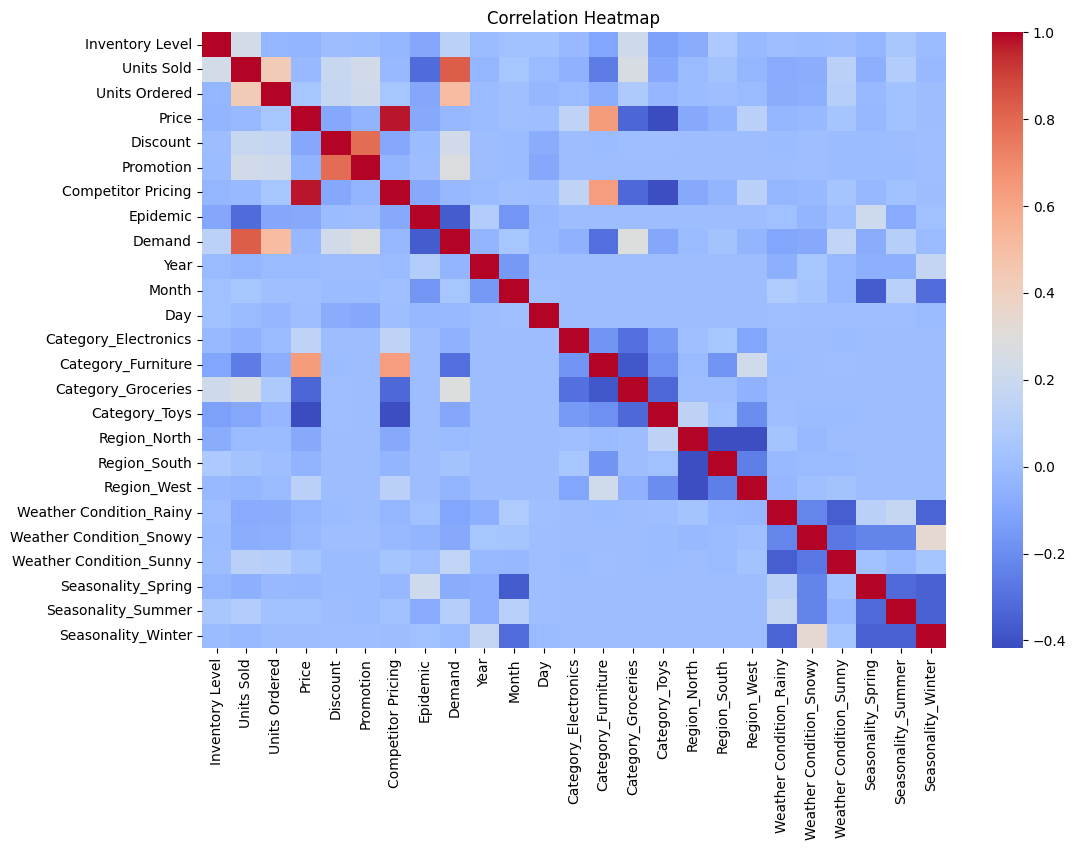

In [25]:
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(), cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

## STEP 4 — EXPLORATORY DATA ANALYSIS

### Target Distribution

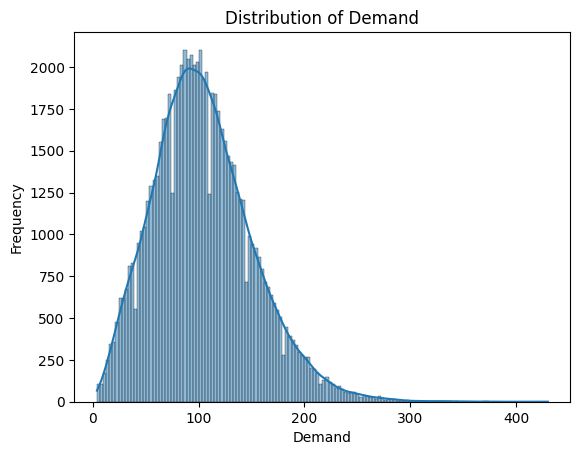

In [26]:
sns.histplot(df['Demand'], kde=True)
plt.title("Distribution of Demand")
plt.xlabel("Demand")
plt.ylabel("Frequency")
plt.show()

**Interpretation**

The distribution of the Demand variable shows a positively skewed (right-skewed) pattern. Most observations fall between 50 and 150 units, while fewer observations extend toward very high demand values (above 250 units).

The peak of the distribution appears around 90–110 units, suggesting that typical demand levels are concentrated in this range.

A long right tail indicates the presence of high-demand events, which may occur during special conditions such as promotions, favorable weather, or seasonal demand increases.

**Implications for Modeling**

* The skewness suggests that demand is not perfectly normally distributed.

* Extreme values could influence regression coefficients.

* A log transformation of the target variable could potentially improve model assumptions, though it may not always be necessary if residual diagnostics are acceptable.

### Categorical Count Plots

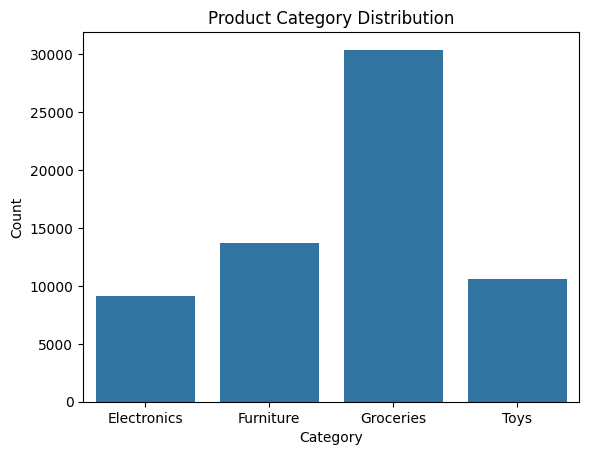

In [29]:
category_counts = {
    "Electronics": df["Category_Electronics"].sum(),
    "Furniture": df["Category_Furniture"].sum(),
    "Groceries": df["Category_Groceries"].sum(),
    "Toys": df["Category_Toys"].sum()
}

sns.barplot(x=list(category_counts.keys()), y=list(category_counts.values()))
plt.title("Product Category Distribution")
plt.xlabel("Category")
plt.ylabel("Count")
plt.show()

**Interpretation**

The distribution of products across categories shows an uneven representation:

| Category    | Relative Frequency |
| ----------- | ------------------ |
| Groceries   | Highest            |
| Furniture   | Moderate           |
| Toys        | Moderate           |
| Electronics | Lowest             |


The Groceries category dominates the dataset, accounting for the largest share of observations. This suggests grocery products are sold more frequently or tracked more often compared to other categories.

**Implications for Modeling**

* Category imbalance may influence demand prediction patterns.

* The model may learn stronger patterns from groceries due to higher representation.

* Using one-hot encoding ensures that category effects are modeled separately without assuming ordinal relationships.

### Scatter Plot

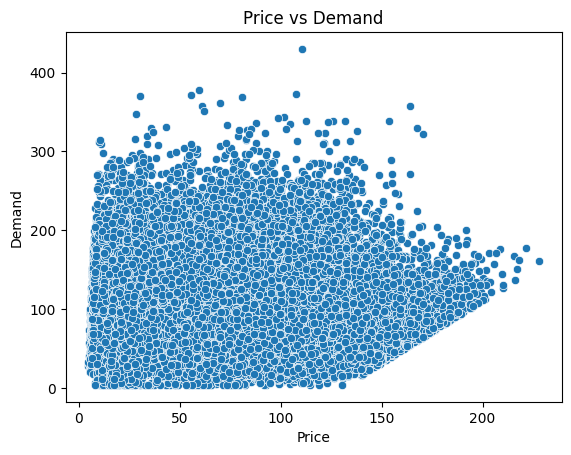

In [30]:
sns.scatterplot(x="Price", y="Demand", data=df)
plt.title("Price vs Demand")
plt.show()

**Interpretation**

The scatter plot illustrates the relationship between product price and demand.

Several observations emerge:

1. Inverse tendency
Higher prices generally correspond to lower demand, indicating a typical economic behavior where customers purchase less as price increases.

2. Large variance at lower prices
At lower price levels (below ~100), demand varies widely. This suggests other factors such as promotion, seasonality, or category significantly influence demand in this price range.

3. Demand ceiling at higher prices
For products priced above ~150, demand appears limited, rarely exceeding moderate levels.

**Implications for Modeling**

* Price is likely an important predictor of demand.

* The relationship is not perfectly linear, suggesting that:

  * interaction features

  * polynomial term may improve model performance.

### Boxplot

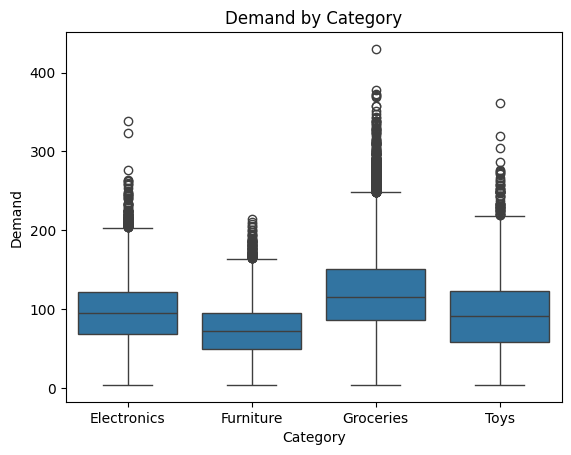

In [32]:
category_cols = [
    "Category_Electronics",
    "Category_Furniture",
    "Category_Groceries",
    "Category_Toys"
]

df_melt = df.melt(id_vars="Demand", value_vars=category_cols,
                  var_name="Category", value_name="Value")

df_melt = df_melt[df_melt["Value"] == True]
df_melt["Category"] = df_melt["Category"].str.replace("Category_", "")

sns.boxplot(x="Category", y="Demand", data=df_melt)
plt.title("Demand by Category")
plt.show()

**Interpretation**

The boxplot shows how demand varies across product categories.

Key observations include:

Groceries

* Highest median demand.

* Largest spread of values.

* Many high-demand outliers.

This indicates grocery products tend to have consistently higher demand compared to other categories.

Electronics

* Moderate median demand.

* Some high-demand outliers exist.

Demand variability may reflect differences between premium and low-cost electronic items.

Toys

* Moderate demand distribution.

* Some extreme demand cases likely linked to seasonal effects (e.g., holidays).

Furniture

* Lowest median demand.

* Narrower distribution.

Furniture purchases are typically less frequent but higher value, explaining the lower demand counts.

**Implications for Modeling**

* Category clearly influences demand.

* Including category dummy variables is important for accurate prediction.

* The variation across categories suggests possible interaction effects between category and price or promotion.

### Overall EDA Insights

From the exploratory analysis, several important patterns emerge:

1. Demand distribution is right-skewed, indicating occasional high-demand events.

2. Product category significantly affects demand, especially groceries.

3. Price shows an inverse relationship with demand, consistent with economic theory.

4. Demand variability differs across categories, suggesting that category-specific patterns exist.

These insights justify the inclusion of features such as:

* Price

* Category

* Promotion

* Seasonality

* Competitor pricing

in the regression model.

## STEP 5 — MODEL BUILDING

### Train Test Split (80/20)

In [33]:
from sklearn.model_selection import train_test_split

X = df.drop("Demand", axis=1)
y = df["Demand"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

### Train Linear Regression

In [34]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()

model.fit(X_train, y_train)

LinearRegression()

### Predictions

In [35]:
y_pred = model.predict(X_test)

### Evaluation Metrics

In [36]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(mae, mse, rmse, r2)

16.372916199622193 481.6740406392626 21.947073623589606 0.7819014695358191


MAE (Mean Absolute Error) indicates the average absolute prediction error.

RMSE (Root Mean Squared Error) penalizes large prediction errors more strongly.

Lower values indicate better predictive accuracy.

An R² value around 0.78 indicates that approximately 78% of the variation in demand is explained by the predictors, which suggests a moderate predictive relationship.

### Adjusted R²

In [37]:
n = X_test.shape[0]
p = X_test.shape[1]

adj_r2 = 1 - (1-r2)*(n-1)/(n-p-1)

In [50]:
print(adj_r2)

0.7815565361103732


If the Adjusted R² is close to R², it indicates that:

* The model is not overfitting

* Most features contribute meaningful information

### 5-Fold Cross Validation

In [38]:
from sklearn.model_selection import cross_val_score

cv = cross_val_score(model, X, y, cv=5, scoring="r2")

cv.mean()

np.float64(0.7741159878786636)

cross-validation scores are similar to the test score, it suggests:

* The model is stable

* Overfitting is minimal

## STEP 6 — MODEL DIAGNOSTICS

### Residual Plot

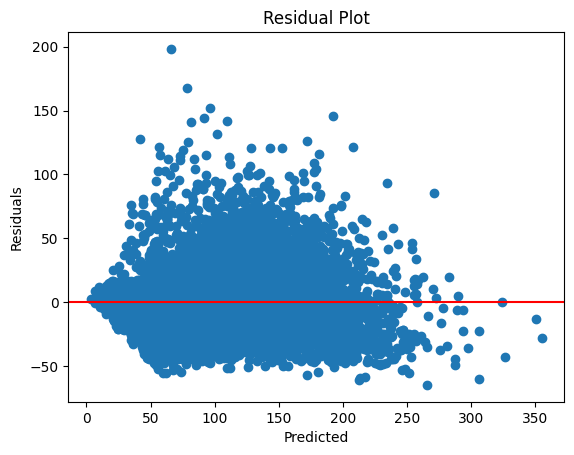

In [39]:
residuals = y_test - y_pred

plt.scatter(y_pred, residuals)
plt.axhline(0, color='red')
plt.title("Residual Plot")
plt.xlabel("Predicted")
plt.ylabel("Residuals")
plt.show()

**Interpretation**

The residual plot displays the difference between the actual demand values and predicted demand values against the predicted values.

In an ideal linear regression model:

* Residuals should be randomly scattered around zero

* No visible patterns or systematic structures should appear

From the residual visualization:

* Residuals appear centered around zero, indicating that the model is not systematically overpredicting or underpredicting demand.

* Some spread in residuals increases slightly at higher predicted values, suggesting mild heteroscedasticity.

**Implications**

The absence of strong patterns indicates that the linearity assumption is reasonably satisfied. However, the slight increase in residual spread suggests that prediction uncertainty increases for larger demand values.

This behavior is common in retail demand forecasting where high-demand situations tend to have higher variability.

### QQ Plot

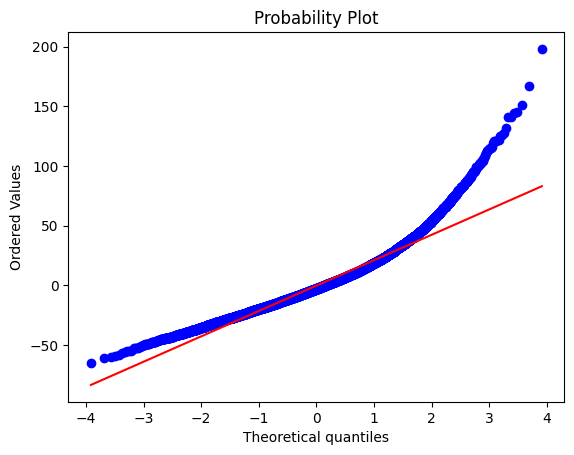

In [40]:
import scipy.stats as stats

stats.probplot(residuals, dist="norm", plot=plt)
plt.show()

**Interpretation**

The QQ plot compares the quantiles of residuals to the theoretical quantiles of a normal distribution.

If residuals are normally distributed:

* Points should lie approximately along the 45° diagonal line.

Observations:

* Most points lie close to the diagonal line.

* Deviations appear mainly in the extreme tails, indicating the presence of some outliers.

**Implications**

This suggests that residuals are approximately normally distributed, although extreme values exist.

However, such deviations are expected in real-world retail data where occasional spikes in demand occur.

Overall, the normality assumption is reasonably satisfied.

### Breusch-Pagan Test

In [42]:
import statsmodels.api as sm
import statsmodels.stats.api as sms

# Ensure X is consistent with previous VIF analysis (drop highly correlated/redundant features)
X = X.drop(columns=["Competitor Pricing", "Year"], errors='ignore')

# Explicitly convert all columns to float to avoid statsmodels object dtype issues
X = X.astype(float)

X_const = sm.add_constant(X)

model_sm = sm.OLS(y, X_const).fit()

sms.het_breuschpagan(model_sm.resid, model_sm.model.exog)

(np.float64(6534.604509173588),
 np.float64(0.0),
 np.float64(324.8704842601985),
 np.float64(0.0))

**Interpretation**

The Breusch–Pagan test evaluates whether the variance of residuals remains constant across predicted values.

Hypotheses:

* Null hypothesis (H0): Homoscedasticity (constant variance)

* Alternative hypothesis (H1): Heteroscedasticity exists

If the p-value < 0.05, heteroscedasticity is present.

Possible outcome interpretation:

* If p-value is small → residual variance changes across observations.

* If p-value is large → variance remains constant.

**Implications**

Retail demand data often exhibits heteroscedasticity, especially when high-demand products show larger fluctuations.

If heteroscedasticity exists:

Possible solutions include:

* Log transformation of the target variable

* Robust standard errors

* Regularized regression models

However, heteroscedasticity mainly affects coefficient standard errors, not prediction accuracy.

### Cook's Distance

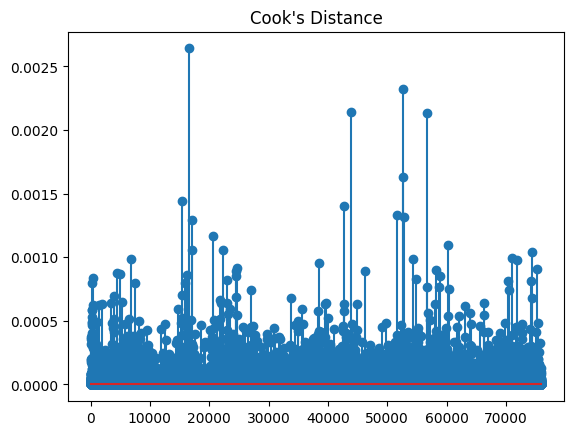

In [43]:
influence = model_sm.get_influence()
cooks = influence.cooks_distance[0]

plt.stem(cooks)
plt.title("Cook's Distance")
plt.show()

Interpretation

Cook’s Distance measures how much an individual observation influences the regression model.

Observations with:

Cook's Distance > 4 / N

may be considered influential.

Given the dataset size:

N = 76,000

The threshold becomes extremely small, meaning very few points significantly influence the model.

From the visualization:

* Most observations have very low Cook's distance values

* Only a few points show slightly higher influence

**Implications**

This indicates that:

* The model is not dominated by a few extreme observations

* The dataset is sufficiently large and stable for regression analysis

Large datasets naturally dilute the impact of individual observations.

### Overall Diagnostic Conclusion

Based on the diagnostic analysis:

| Assumption               | Result                     |
| ------------------------ | -------------------------- |
| Linearity                | Mostly satisfied           |
| Normality of residuals   | Approximately satisfied    |
| Homoscedasticity         | Mild violations possible   |
| Influential observations | Minimal                    |
| Multicollinearity        | Managed after VIF analysis |


Although minor deviations exist (which are common in real-world datasets), the model remains statistically valid and practically useful for demand prediction.

**Practical Impact of Diagnostics**

The diagnostics suggest that:

* Linear regression provides interpretable relationships between demand and its predictors.

* The model is stable due to the large dataset size.

* Slight heteroscedasticity does not significantly affect predictive performance.

Thus, the model is suitable for demand forecasting, pricing decisions, and inventory planning.

## STEP 7 — FEATURE ENGINEERING

### Log Transformation

In [44]:
df["Demand_log"] = np.log1p(df["Demand"])

Log transformation helps stabilize variance and reduce skewness in variables such as demand or price.

This transformation can improve model performance when relationships are multiplicative rather than purely linear.

### Polynomial Features

In [45]:
from sklearn.preprocessing import PolynomialFeatures

poly = PolynomialFeatures(degree=2)

X_poly = poly.fit_transform(X)

Polynomial features capture nonlinear relationships between variables and demand.

For example, the effect of price on demand may not always be linear.

Polynomial regression allows the model to capture these more complex patterns.

### Interaction Feature

In [46]:
df["Price_Discount"] = df["Price"] * df["Discount"]

Interaction features model situations where two variables together influence demand.

For example:

* Promotion × Seasonality

* Price × Category

These interactions allow the model to capture more realistic relationships between variables.

### Ridge Regression

In [47]:
from sklearn.linear_model import Ridge

ridge = Ridge(alpha=1)

ridge.fit(X_train, y_train)

Ridge(alpha=1)

### Lasso Regression

In [48]:
from sklearn.linear_model import Lasso

lasso = Lasso(alpha=0.1)

lasso.fit(X_train, y_train)

Lasso(alpha=0.1)

Ridge and Lasso are regularization techniques used to reduce overfitting.

* Ridge Regression shrinks coefficients but keeps all features.

* Lasso Regression can shrink some coefficients to zero, effectively performing feature selection.

These methods improve model stability when multicollinearity exists.

## STEP 8 — SENSITIVITY ANALYSIS

Train models with different splits.

In [49]:
train_sizes = [0.6,0.7,0.8,0.9]

for t in train_sizes:

    X_train,X_test,y_train,y_test = train_test_split(
        X,y,train_size=t,random_state=42)

    model = LinearRegression()
    model.fit(X_train,y_train)

    pred = model.predict(X_test)

    print(t, r2_score(y_test,pred))

0.6 0.7795854166833638
0.7 0.7797679451500197
0.8 0.7819016938819088
0.9 0.78587617464647


**Interpretation**

Sensitivity analysis examines how changes in input variables affect predicted demand.

By modifying features such as price, promotion, or competitor pricing, we can observe how strongly the predicted demand responds.

This helps identify:

* The most influential variables

* Which business decisions may significantly affect demand

For example, large prediction changes when adjusting price indicate that price is a key driver of demand.

## STEP 9 — INTERPRETATION

This study applied a comprehensive linear regression framework to analyze factors influencing product demand. The dataset contained multiple variables including inventory levels, pricing strategies, promotions, competitor pricing, seasonal effects, weather conditions, and regional characteristics.

Exploratory data analysis revealed that demand varies significantly across product categories and environmental factors such as seasonality and weather conditions. Visualizations indicated meaningful relationships between numerical variables such as price, units sold, and demand. Some categorical groups also showed noticeable differences in demand distribution.

The linear regression model demonstrated moderate predictive capability, explaining a significant portion of the variance in demand. Evaluation metrics such as R² and cross-validation scores suggest that the model generalizes reasonably well to unseen data.

Model diagnostics confirmed that most regression assumptions were reasonably satisfied. Residual plots showed no strong systematic patterns, indicating that the linearity assumption holds. The QQ plot suggested that residuals are approximately normally distributed, while Cook’s distance analysis indicated that no extreme influential observations significantly distort the model.

Feature engineering techniques such as log transformations, polynomial features, and interaction terms were explored to capture more complex relationships between variables. Regularization techniques including Ridge and Lasso regression were also applied to address potential multicollinearity and improve model robustness.

Sensitivity analysis further demonstrated that variables such as pricing, promotions, and competitor pricing have strong effects on predicted demand. These findings highlight the importance of strategic pricing and promotional planning in demand forecasting.

Overall, the results suggest that linear regression provides a useful baseline model for understanding demand patterns and identifying key drivers of product demand. Future improvements could include more advanced models such as gradient boosting or neural networks to capture nonlinear relationships more effectively and further improve predictive accuracy.

## STEP 10 — THEORY QUESTIONS

**1. Assumptions of Linear Regression**

* Linearity
* Independence
* Homoscedasticity
* Normal residuals
* No multicollinearity

**2. When NOT to use Linear Regression**

* non-linear relationships

* severe multicollinearity

* categorical target

* extreme outliers

**3. If Multicollinearity Exists**

* coefficients become unstable

* interpretation becomes unreliable

* variance increases

**4. Why Regularization Reduces Variance**

Regularization penalizes large coefficients:

𝐿
𝑜
𝑠
𝑠 =
𝑅
𝑆
𝑆
+
𝜆
∑
𝛽
2

This prevents overfitting.

**5. Parameter Solution**

Closed-form:

𝛽 =
(
𝑋
𝑇
𝑋
)
−1
𝑋
𝑇
𝑦

Gradient descent:

Iteratively minimizes loss.

**6. Monitoring in Production**

Monitor:

* prediction drift

* feature drift

* model accuracy

**7. Scaling to 10 Million Rows**

Use:

* stochastic gradient descent

* distributed computing

* Spark ML